In [1]:
import os
os.chdir('../')
%pwd

'/Users/kiranprasadjp/Documents/Pros/HHMI_Janelia_AI_Engineer'

In [2]:
from dataclasses import dataclass
from pathlib import Path


@dataclass(frozen=True)
class VizConfig:
    root_dir: Path
    dense_embd: Path
    local_data: Path
    outwithin:Path
    out:Path

In [3]:
from src.task2 import logger
from src.task2.constants import *
from src.task2.utils.common import read_yaml, create_directories

In [4]:
class ConfigurationManager:
    def __init__(
        self,
        config_filepath = CONFIG_FILE_PATH,
        params_filepath = PARAMS_FILE_PATH):

        self.config = read_yaml(config_filepath)
        self.params = read_yaml(params_filepath)

        create_directories([self.config.artifacts_root])


    
    def get_viz_config(self) -> VizConfig:
        config = self.config.viz

        create_directories([config.root_dir])

        viz_config = VizConfig(
            root_dir=Path(config.root_dir),
            dense_embd=Path(config.Dense_embedding),
            local_data=Path(config.local_data_file),
            outwithin= Path(config.OUTPUT_within),
            out=Path(config.OUTPUT)
            
            
        )

        return viz_config

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import normalize
import torch
from src.task2.utils.common import save_json
import matplotlib.gridspec as gridspec

In [6]:
class WithinDatasetRetrival:
    def __init__(self,config:VizConfig ):
        self.config=config
        embed= input("Dense Embeddings| What is the name of file? (e.g., dense.pt): ")
        emfile=os.path.join(self.config.dense_embd,embed)
        self.embeddings = torch.load(emfile).numpy()
        localfile= input("Local File Input| What is the name of file? (e.g., liver.npy): ")
        lf=os.path.join(self.config.local_data,localfile)
        self.lf=lf
        self.raw_data   = np.load(lf)

        self.c, self.z, self.h, self.w = self.embeddings.shape
        flat = self.embeddings.reshape(self.c, -1).T
        self.flat_embeddings = normalize(flat, norm='l2')
        logger.info(
            f'Loaded embeddings : {self.embeddings.shape}\n'
            f'Raw volume        : {self.raw_data.shape}\n'
            f'Flat index        : {self.flat_embeddings.shape}'
        )
    def get_query_vector(self, z:int, y:int, x:int, window: int=8)-> np.ndarray:
        y_end = min(y + window, self.h)
        x_end = min(x + window, self.w)
        query_patch = self.embeddings[:, z, y:y_end, x:x_end]    
        return np.mean(query_patch, axis=(1, 2)).reshape(1, -1)
    
    def get_query_from_box(
        self,
        z: int,
        y_min: int, y_max: int,
        x_min: int, x_max: int,
    ) -> np.ndarray:
        """
        Mean-pool embeddings inside a full bounding box.
        Prefer this over get_query_vector for whole-mitochondrion queries.
        """
        roi = self.embeddings[:, z, y_min:y_max, x_min:x_max]  # [C, H_roi, W_roi]
        vec = roi.mean(axis=(1, 2))
        vec = vec / (np.linalg.norm(vec) + 1e-8)
        return vec.reshape(1, -1)

    
    def compute_heatmap(self, query_vec: np.ndarray) -> np.ndarray:
        """
        Dot product of pre-normalised embeddings = cosine similarity.
        Returns similarity volume [Z, H, W] in [-1, 1].
        """
        q   = normalize(query_vec, norm='l2')               # [1, C]
        sim = self.flat_embeddings @ q.T                    # [N, 1]
        return sim.reshape(self.z, self.h, self.w)
    
    def precision_at_k(self,sim_map:np.ndarray,z:int,y_min: int, y_max: int,x_min: int, x_max: int,k:int = 500,) -> dict:
        """
        Treat pixels inside the query bounding box as positives.
        Rank all pixels by similarity and compute Precision@k and Recall@k.
        """
        # Ground-truth positive mask
        gt_mask        = np.zeros((self.z, self.h, self.w), dtype=bool)
        gt_mask[z, y_min:y_max, x_min:x_max] = True
        gt_flat        = gt_mask.flatten()
        sim_flat       = sim_map.flatten()

        # Rank pixels descending by similarity
        ranked_idx     = np.argsort(sim_flat)[::-1]
        top_k_idx      = ranked_idx[:k]

        tp             = gt_flat[top_k_idx].sum()
        total_pos      = gt_flat.sum()

        precision_k    = tp / k
        recall_k       = tp / (total_pos + 1e-8)
        f1             = (2 * precision_k * recall_k / (precision_k + recall_k + 1e-8))

        results = {
            'Dataset Name': self.lf,
            'precision@k' : round(precision_k, 4),
            'recall@k'    : round(recall_k,    4),
            'f1@k'        : round(f1,           4),
            'k'           : k,
            'total_pos'   : int(total_pos),
        }
        save_json(path=Path(self.config.outwithin), data=results)

        logger.info('\n[Quantitative — Within-dataset]')
        for key, val in results.items():
            logger.info(f'  {key:<14}: {val}')

        return results
    
    def plot_overlay(self,z_slice:int,sim_map:np.ndarray,threshold:float = 0.70,query_box: dict|None=None,
                     title:str = 'Within-dataset retrieval'):
        """
        Four-panel figure:
          [0] Raw EM slice
          [1] Full similarity heatmap
          [2] Thresholded overlay
          [3] Similarity score histogram
        """
        heatmap        = sim_map[z_slice]
        masked_heatmap = np.ma.masked_where(heatmap < threshold, heatmap)

        fig = plt.figure(figsize=(18, 5))
        fig.patch.set_facecolor('#0e1410')
        gs  = gridspec.GridSpec(1, 4, figure=fig, wspace=0.12,
                                left=0.03, right=0.97)

        panel_titles = [
            'Raw EM slice',
            'Full similarity map',
            f'Threshold ≥ {threshold}',
            'Score distribution',
        ]

        # ── Panel 0: raw slice ─────────────────────────────────────────────────
        ax0 = fig.add_subplot(gs[0])
        ax0.imshow(self.raw_data[z_slice], cmap='gray')
        if query_box:
            import matplotlib.patches as mpatches
            rect = mpatches.Rectangle(
                (query_box['x_min'], query_box['y_min']),
                query_box['x_max'] - query_box['x_min'],
                query_box['y_max'] - query_box['y_min'],
                linewidth=2, edgecolor='#4ade80', facecolor='none',
            )
            ax0.add_patch(rect)
            ax0.text(
                query_box['x_min'], query_box['y_min'] - 6,
                'Query', color='#4ade80', fontsize=8,
            )
        

        # ── Panel 1: full heatmap ──────────────────────────────────────────────
        ax1  = fig.add_subplot(gs[1])
        im1  = ax1.imshow(heatmap, cmap='coolwarm', vmin=-1, vmax=1)
        fig.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04,
                     label='Cosine similarity')

        # ── Panel 2: thresholded overlay ───────────────────────────────────────
        ax2 = fig.add_subplot(gs[2])
        ax2.imshow(self.raw_data[z_slice], cmap='gray')
        im2 = ax2.imshow(masked_heatmap, cmap='viridis',
                         alpha=0.65, vmin=threshold, vmax=1.0)
        fig.colorbar(im2, ax=ax2, fraction=0.046, pad=0.04,
                     label='Cosine similarity')

        # ── Panel 3: histogram ─────────────────────────────────────────────────
        ax3 = fig.add_subplot(gs[3])
        ax3.set_facecolor('#141c16')
        ax3.hist(heatmap.flatten(), bins=60,
                 color='#1D9E75', edgecolor='#0e1410', linewidth=0.4)
        ax3.axvline(threshold, color='#f472b6', linewidth=1.5,
                    label=f'threshold={threshold}')
        ax3.axvline(heatmap.mean(), color='#4ade80', linewidth=1.2,
                    linestyle='--', label=f'mean={heatmap.mean():.3f}')
        ax3.set_xlabel('Cosine similarity', color='#6b8f72', fontsize=9)
        ax3.set_ylabel('Pixel count',       color='#6b8f72', fontsize=9)
        ax3.tick_params(colors='#6b8f72', labelsize=8)
        ax3.legend(fontsize=8, labelcolor='#e8f5ec',
                   facecolor='#0e1410', edgecolor='#1D9E75')
        for sp in ax3.spines.values():
            sp.set_edgecolor('#1D9E75')

        # ── Shared formatting ──────────────────────────────────────────────────
        for ax, ptitle in zip([ax0, ax1, ax2, ax3], panel_titles):
            ax.set_title(ptitle, color='#e8f5ec', fontsize=10, pad=6)
            if ax != ax3:
                ax.axis('off')

        fig.suptitle(f'{title}  —  z={z_slice}',
                     color='#e8f5ec', fontsize=13, fontweight='bold', y=1.01)
        save_name= input('Saving Plot| Provide name(e.g: within.png):')
        save_path= os.path.join(self.config.out, save_name)
        if save_path:
            plt.savefig(save_path, dpi=150, bbox_inches='tight',
                        facecolor=fig.get_facecolor())
            logger.info(f'Saved → {save_path}')

        plt.show()
        return fig


[2026-04-06 02:56:41,400: INFO: common: yaml file: config/config.yaml loaded successfully]
[2026-04-06 02:56:41,402: INFO: common: yaml file: params.yaml loaded successfully]
[2026-04-06 02:56:41,403: INFO: common: created directory at: artifacts]
[2026-04-06 02:56:41,404: INFO: common: created directory at: artifacts/retri_viz]
[2026-04-06 02:56:56,721: INFO: 277049829: Loaded embeddings : (384, 6, 448, 448)
Raw volume        : (6, 448, 448)
Flat index        : (1204224, 384)]
[2026-04-06 02:56:57,632: INFO: common: json file saved at: OUTPUT/withinRet.json]
[2026-04-06 02:56:57,633: INFO: 277049829: 
[Quantitative — Within-dataset]]
[2026-04-06 02:56:57,633: INFO: 277049829:   Dataset Name  : artifacts/data_ingestion/ps1.npy]
[2026-04-06 02:56:57,634: INFO: 277049829:   precision@k   : 1.0]
[2026-04-06 02:56:57,634: INFO: 277049829:   recall@k      : 0.1429]
[2026-04-06 02:56:57,635: INFO: 277049829:   f1@k          : 0.25]
[2026-04-06 02:56:57,635: INFO: 277049829:   k             :

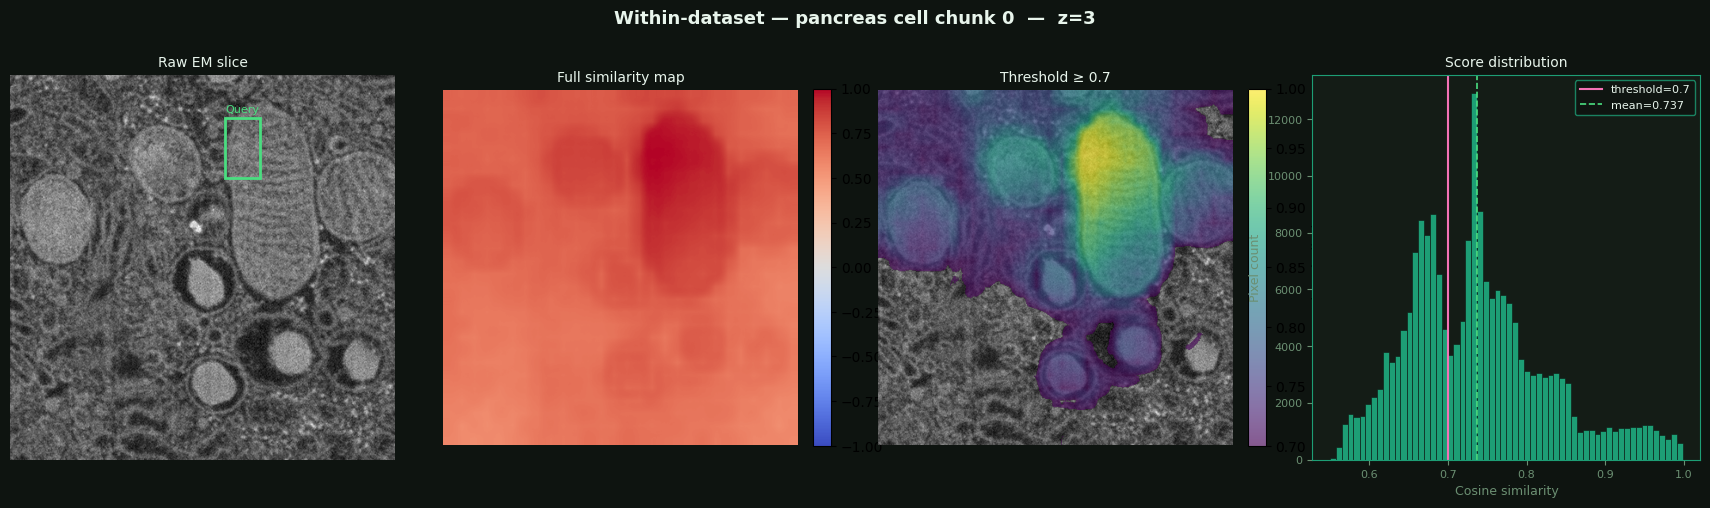

: 

In [ ]:
try:
    config = ConfigurationManager()
    viz_config = config.get_viz_config()
    retriever = WithinDatasetRetrival(config=viz_config)
    # query_vec = retriever.get_query_vector(z=3, y=200, x=200, window=3)
    query_box = {'z': 3, 'y_min': 50, 'y_max': 120, 'x_min': 250, 'x_max': 290}
    query_vec = retriever.get_query_from_box(**query_box) 
    sim_map = retriever.compute_heatmap(query_vec)
    metrics = retriever.precision_at_k(sim_map, z=query_box['z'],y_min=query_box['y_min'], y_max=query_box['y_max'],
        x_min=query_box['x_min'], x_max=query_box['x_max'],
        k=400,)
    retriever.plot_overlay(
        z_slice   = 3,
        sim_map   = sim_map,
        threshold = 0.7,
        query_box=query_box,
        title     = 'Within-dataset — pancreas cell chunk 0',
    )    
    
except Exception as e:
    raise e

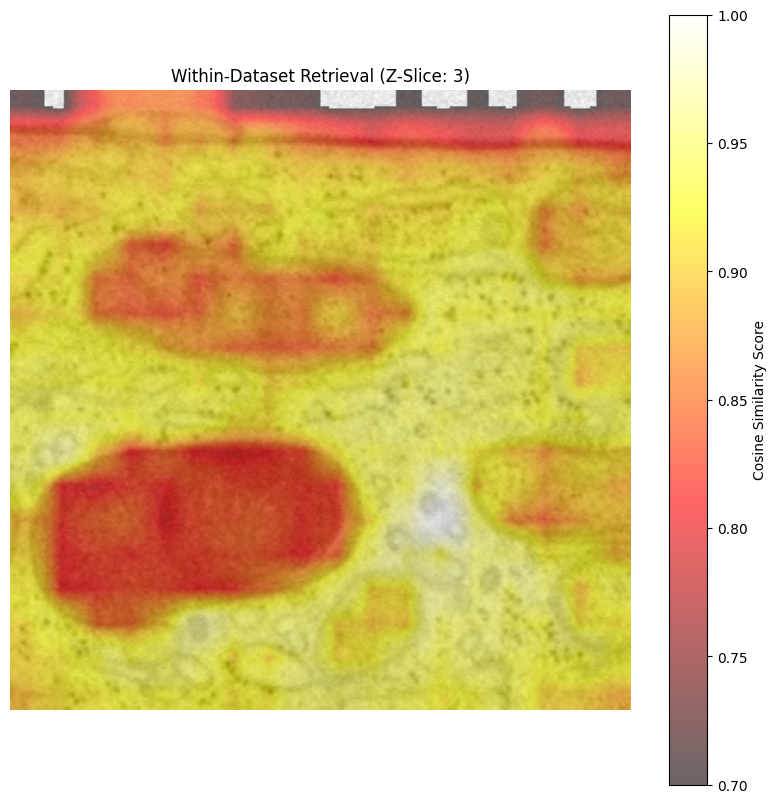

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from sklearn.metrics.pairwise import cosine_similarity

class WithinDatasetRetriever:
    def __init__(self, embedding_path, raw_path):
        # Load the DINOv3 384-dim fingerprints and the raw EM data
        self.embeddings = torch.load(embedding_path).numpy() # Expected: (384, Z, H, W)
        self.raw_data = np.load(raw_path)         # Expected: (Z, H, W)
        
        # Flatten spatial dimensions for matrix operations: (384, N) -> (N, 384)
        self.c, self.z, self.h, self.w = self.embeddings.shape
        self.flat_embeddings = self.embeddings.reshape(self.c, -1).T

    def get_query_vector(self, z, y, x, window=3):
        """Extracts the average embedding of a selected mitochondrion."""
        query_patch = self.embeddings[:, z, y:y+window, x:x+window]
        return np.mean(query_patch, axis=(1, 2)).reshape(1, -1)

    def compute_heatmap(self, query_vec):
        """Calculates similarity between the query and all other pixels."""
        # Cosine Similarity returns a value between 0 (different) and 1 (identical)
        sim = cosine_similarity(self.flat_embeddings, query_vec)
        return sim.reshape(self.z, self.h, self.w)

    def plot_overlay(self, z_slice, sim_map, threshold=0.7):
        """Overlays the similarity 'glow' onto the raw EM slice."""
        plt.figure(figsize=(10, 10))
        
        # Display base EM image
        plt.imshow(self.raw_data[z_slice], cmap='gray')
        
        # Mask out low-similarity areas (cytoplasm, nucleus) to focus on mitochondria
        heatmap = sim_map[z_slice]
        masked_heatmap = np.ma.masked_where(heatmap < threshold, heatmap)
        
        # Overlay the heatmap (hot colors indicate high similarity)
        plt.imshow(masked_heatmap, cmap='hot', alpha=0.6, vmin=threshold, vmax=1.0)
        
        plt.title(f"Within-Dataset Retrieval (Z-Slice: {z_slice})")
        plt.colorbar(label="Cosine Similarity Score")
        plt.axis('off')
        plt.show()

# --- Example Usage for Liver Chunk ---
retriever = WithinDatasetRetriever(
    'artifacts/models/den_hela_30_s0.pt', 
    'artifacts/data_ingestion/hela_cell_chunk_s0.npy'
)

# 1. Define query coordinates (a point you know is a mitochondrion)
query_vec = retriever.get_query_vector(z=3, y=200, x=200)

# 2. Search the volume
sim_map = retriever.compute_heatmap(query_vec)

# 3. Visualize the "Digital Magnet" effect
retriever.plot_overlay(z_slice=3, sim_map=sim_map)